<div style="background-color: RGB(93, 173, 226);" >
    <center> 
        <h1 style="margin: auto; padding: 20px; color:#fff; ">  Anticipez les besoins en consommation de bâtiments </h1> 
    </center>
</div>

<div style="background-color: RGB(93, 173, 226);" >
    <h3 style="margin: auto; padding: 20px; color:#fff; "> III - Prédiction de la consommation totale d’énergie </h3>
</div>

<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> Importation des utilitaires </h4>
</div>

In [47]:
import polars as pl
import numpy as np
import pandas as pd
import statsmodels.api as sm
import category_encoders as ce
import shap

from sklearn.ensemble import GradientBoostingRegressor, BaggingRegressor,RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer, mean_squared_error
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.svm import SVR

import matplotlib.pyplot as plt
import seaborn as sns

<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> chargement des données clean </h4>
</div>

In [48]:
# Données clean
df = pl.read_csv("data_batiment_2016_clean.csv")
df.head()

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,SiteEUI(kBtu/sf),SiteEnergyUse(kBtu),GHGEmissionsIntensity,ENERGYSTARScore,Electricity_Proportion(kBtu),SteamUse_Proportion(kBtu)
i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,1,1927,1.0,12.0,88434.0,81.699997,7226362.5,2.83,60.0,0.54606,0.277302
1,2,1996,1.0,11.0,103566.0,94.800003,8.387933e6,2.86,61.0,0.297569,0.23031
2,3,1969,1.0,2.0,47237.0,96.0,2.6152e6,2.19,43.0,0.405656,0.223646
3,5,1926,1.0,10.0,61320.0,110.800003,6.794584e6,4.67,56.0,0.407519,0.325913
4,8,1980,1.0,18.0,175580.0,114.800003,1.4172606e7,2.88,75.0,0.290734,0.23249


In [49]:
# Séparation des variables explicatives (X) et de la variable cible (Y)
X = df.select(pl.exclude(["SiteEnergyUse(kBtu)", "OSEBuildingID", "ENERGYSTARScore"]))
Y = df.select("SiteEnergyUse(kBtu)")

In [50]:
X.head()

,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,SiteEUI(kBtu/sf),GHGEmissionsIntensity,Electricity_Proportion(kBtu),SteamUse_Proportion(kBtu)
i64,i64,f64,f64,f64,f64,f64,f64,f64
0,1927,1.0,12.0,88434.0,81.699997,2.83,0.54606,0.277302
1,1996,1.0,11.0,103566.0,94.800003,2.86,0.297569,0.23031
2,1969,1.0,2.0,47237.0,96.0,2.19,0.405656,0.223646
3,1926,1.0,10.0,61320.0,110.800003,4.67,0.407519,0.325913
4,1980,1.0,18.0,175580.0,114.800003,2.88,0.290734,0.23249


#### Séparation des données en ensembles d'entraînement et de test

In [51]:
# Appliquons un TargetEncoder sur les colonnes qualitatives

# reconvertis-le en DataFrame
X = X.to_pandas()
# Reshape Y pour éviter l'avertissement
Y = Y.to_numpy().ravel()

# Détection des colonnes qualitatives
cat_cols = X.select_dtypes(include= ['object', 'category']).columns.tolist()

# TargetEncoder
encoder = ce.TargetEncoder(cols= cat_cols)
data_encoded = encoder.fit_transform(X, Y)

# Affichage
data_encoded.head()

,,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,SiteEUI(kBtu/sf),GHGEmissionsIntensity,Electricity_Proportion(kBtu),SteamUse_Proportion(kBtu)
0,0,1927,1.0,12.0,88434.0,81.699997,2.83,0.546060,0.277302
1,1,1996,1.0,11.0,103566.0,94.800003,2.86,0.297569,0.230310
2,2,1969,1.0,2.0,47237.0,96.000000,2.19,0.405656,0.223646
3,3,1926,1.0,10.0,61320.0,110.800003,4.67,0.407519,0.325913
4,4,1980,1.0,18.0,175580.0,114.800003,2.88,0.290734,0.232490


In [52]:
# 20% des données sont utilisées pour le test, et 80% pour l'entraînement et séparation reproductible à 42
X_train, X_test, y_train, y_test = train_test_split(data_encoded, Y, test_size=0.2, random_state=42)

In [53]:
# Correction de la forme de y_train
#y_train = y_train.to_numpy().ravel()

In [54]:
# Normalisation des données
scaler = StandardScaler()
# Ajustement des données d'entraînement
X_train_scaled = scaler.fit_transform(X_train)
# Normalisation des données de test
X_test_scaled = scaler.transform(X_test)

<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> III.0- Modèle de régression par boosting lasticNet </h4>
</div>

In [55]:
# Initialisation du modèle ElasticNet
model = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)

# Entraînement
model.fit(X_train_scaled, y_train)

# Prédiction
y_pred = model.predict(X_test_scaled)

# Évaluation
el_r2 = r2_score(y_test, y_pred)
el_mae = mean_absolute_error(y_test, y_pred)
el_rmse = mean_squared_error(y_test, y_pred)

# Validation croisée (MSE moyenne)
el_mse_cv = -cross_val_score(model, X_train_scaled, y_train, scoring='neg_mean_squared_error', cv=5).mean()

# Résultats
print("ElasticNet Evaluation :")
print("===================================")
print(f"R2 Score                : {el_r2:.4f}")
print(f"MAE (erreur absolue)    : {el_mae:.2f}")
print(f"RMSE (racine MSE)       : {el_rmse:.2f}")
print("===============")
print("Validation croisée :")
print("===================================")
print(f"MSE Validation croisée  : {el_mse_cv:.2f}")

ElasticNet Evaluation :
R2 Score                : 0.5694
MAE (erreur absolue)    : 1361420.33
RMSE (racine MSE)       : 4261354439939.83
Validation croisée :
MSE Validation croisée  : 4609377854767.17


<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> III.1 - Modèle de régression par boosting (GradientBoostingRegressor) </h4>
</div>

In [56]:
# Création du modèle de régression par boosting (Utilisation de GradientBoostingRegressor)
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
# Entraînement du modèle
gb_model.fit(X_train_scaled, y_train)
# Prédictions
gb_model_pred = gb_model.predict(X_test_scaled)

In [57]:
# Evaluation du modèle GradientBoostingRegressor
gb_model_r2 = r2_score(y_test, gb_model_pred)
gb_model_mae = mean_absolute_error(y_test, gb_model_pred)
gb_model_rmse = mean_squared_error(y_test, gb_model_pred)

# Validation croisée
gb_model_cv = cross_val_score(gb_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')

# Affichage des résultats
print("GradientBoostingRegressor Evaluation :")
print("===================================")
print(f"R2 Score : {gb_model_r2}")
print(f"MAE moyen : {gb_model_mae}")
print(f"RMSE moyen : {gb_model_rmse}")
print("===============")
print("Validation croisée :")
print("===================================")
print(f"MSE moyen : {-gb_model_cv.mean()}")

GradientBoostingRegressor Evaluation :
R2 Score : 0.8353974608366361
MAE moyen : 670467.6279503349
RMSE moyen : 1628862475198.1282
Validation croisée :
MSE moyen : 1955389019406.4094


<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> III.2 - Modèle SVM </h4>
</div>

In [58]:
# Définition du modèle SVM avec noyau RBF (pour les relations non linéaires)
svm_model = SVR(kernel='rbf')
# Entraînement du modèle SVM
svm_model.fit(X_train_scaled, y_train)
# Prédictions
svm_model_pred = svm_model.predict(X_test_scaled)

In [59]:
# Evaluation du modèle SVM
svm_model_r2 = r2_score(y_test, svm_model_pred)
svm_model_mae = mean_absolute_error(y_test, svm_model_pred)
svm_model_rmse = mean_squared_error(y_test, svm_model_pred)
#svm_model_rmse = mean_squared_error(svm_model_mse)

# Validation croisée avec 5 plis
svm_model_cv = cross_val_score(svm_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')

# Affichage des résultats
print("SVM Evaluation :")
print("===================================")
print(f"R2 Score : {svm_model_r2}")
print(f"MAE moyen : {svm_model_mae}")
print(f"RMSE moyen : {svm_model_rmse}")
print("==================")
print("Validation croisée :")
print("===================================")
print(f"MSE moyen : {-svm_model_cv.mean()}")

SVM Evaluation :
R2 Score : -0.08446902850446025
MAE moyen : 2100931.2465756866
RMSE moyen : 10731613953368.77
Validation croisée :
MSE moyen : 13461657793824.05


<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> III.3 - Modèle andom Forest </h4>
</div>

In [60]:
#Définition du modèle random forest
rf_model =  RandomForestRegressor(random_state=42)
# Entraînement du modèle
rf_model.fit(X_train_scaled, y_train)
# Prédictions
rf_model_pred = rf_model.predict(X_test_scaled)

In [61]:
# Evaluation du modèle RandomForestRegressor
rf_model_r2 = r2_score(y_test, rf_model_pred)
rf_model_mae = mean_absolute_error(y_test, rf_model_pred)
rf_model_rmse = mean_squared_error(y_test, rf_model_pred)

# Validation croisée
rf_model_cv = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')

# Affichage des résultats
print("RandomForestRegressor Evaluation :")
print("===================================")
print(f"R2 Score : {rf_model_r2}")
print(f"MAE moyen : {rf_model_mae}")
print(f"RMSE moyen : {rf_model_rmse}")
print("===============")
print("Validation croisée :")
print("===================================")
print(f"MSE moyen : {-rf_model_cv.mean()}")

RandomForestRegressor Evaluation :
R2 Score : 0.8515728603487257
MAE moyen : 588989.3832997445
RMSE moyen : 1468795070281.4182
Validation croisée :
MSE moyen : 1689039593432.0364


<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> III.4 - Comparaison des modèles </h4>
</div>

In [63]:
# Création d'un DataFrame pour stocker les résultats
results = pd.DataFrame({
    'Model': ['ElasticNet', 'GradientBoostingRegressor', 'SVM', 'RandomForestRegressor'],
    'R2 Score': [el_r2, gb_model_r2, svm_model_r2, rf_model_r2],
    'MAE moyen': [el_mae, gb_model_mae, svm_model_mae, rf_model_mae],
    'RMSE moyen': [el_rmse, gb_model_rmse, svm_model_rmse, rf_model_rmse],
    'Validation croisée MSE moyen': [el_mse_cv, -gb_model_cv.mean(), -svm_model_cv.mean(), -rf_model_cv.mean()]
})
results_df = pl.DataFrame(results)
# Affichage des résultats
print("===================================")
print("Résultats des modèles :")
print("===================================")
print(results_df)  

Résultats des modèles :
shape: (4, 5)
┌───────────────────────────┬───────────┬──────────────┬────────────┬──────────────────────────────┐
│ Model                     ┆ R2 Score  ┆ MAE moyen    ┆ RMSE moyen ┆ Validation croisée MSE moyen │
│ ---                       ┆ ---       ┆ ---          ┆ ---        ┆ ---                          │
│ str                       ┆ f64       ┆ f64          ┆ f64        ┆ f64                          │
╞═══════════════════════════╪═══════════╪══════════════╪════════════╪══════════════════════════════╡
│ ElasticNet                ┆ 0.569374  ┆ 1.3614e6     ┆ 4.2614e12  ┆ 4.6094e12                    │
│ GradientBoostingRegressor ┆ 0.835397  ┆ 670467.62795 ┆ 1.6289e12  ┆ 1.9554e12                    │
│ SVM                       ┆ -0.084469 ┆ 2.1009e6     ┆ 1.0732e13  ┆ 1.3462e13                    │
│ RandomForestRegressor     ┆ 0.851573  ┆ 588989.3833  ┆ 1.4688e12  ┆ 1.6890e12                    │
└───────────────────────────┴───────────┴────────────

##### Conclusion et choix :

Le RandomForestRegressor est le modèle le plus robuste, car son Coefficient de Détermination (R² Score) est le  plus élevé (0.85) Les autres indicateurs étend relatif aux données. Il est donc recommandé de l'utiliser pour cette tâche.

<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> III.5 - Hyperparametrage et évaluation du modèle </h4>
</div>

In [64]:
# Définition des hyperparamètres pour le random forest
param_grid = {
    'n_estimators': [50, 100, 200], # Nombre d'arbres dans la forêt
    'max_depth': [None, 10, 20], # Profondeur maximale des arbres
    'min_samples_split': [2, 5, 10], # Nombre minimum d'échantillons requis pour diviser un nœud
    'min_samples_leaf': [1, 2, 4], # Nombre minimum d'échantillons requis pour être à une feuille
    #'max_features': ['auto', 'sqrt'], # Nombre de caractéristiques à considérer lors de la recherche de la meilleure séparation
    'min_impurity_decrease': [0.0, 0.01, 0.1] # Seuil pour la réduction de l'impureté
}

# Création de la recherche par grille
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
# Entraînement de la recherche par grille
grid_search.fit(X_train_scaled, y_train)
# Meilleurs hyperparamètres
best_params = grid_search.best_params_
# Meilleur score
best_score = -grid_search.best_score_
# Affichage des meilleurs hyperparamètres et du meilleur score
print("===================================")
print("Meilleurs hyperparamètres :")                
print("===================================")
print(best_params)
print("Meilleur score (Validation croisée MSE moyen) :")
print(best_score)

Meilleurs hyperparamètres :
{'max_depth': 10, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Meilleur score (Validation croisée MSE moyen) :
1684736286549.737


In [65]:
# Création du modèle RandomForestRegressor avec les meilleurs hyperparamètres
rf_model_best = RandomForestRegressor(**best_params, random_state=42)
# Entraînement du modèle avec les meilleurs hyperparamètres
rf_model_best.fit(X_train_scaled, y_train)
# Prédictions
rf_model_best_pred = rf_model_best.predict(X_test_scaled)

In [66]:
# Evaluation du modèle RandomForestRegressor avec les meilleurs hyperparamètres
rf_model_best_r2 = r2_score(y_test, rf_model_best_pred)
rf_model_best_mae = mean_absolute_error(y_test, rf_model_best_pred)
rf_model_best_rmse = mean_squared_error(y_test, rf_model_best_pred)
# Validation croisée
rf_model_best_cv = cross_val_score(rf_model_best, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
# Affichage des résultats
print("===================================")
print("RandomForestRegressor avec meilleurs hyperparamètres Evaluation :")
print("===================================")
print(f"R2 Score : {rf_model_best_r2}")
print(f"MAE moyen : {rf_model_best_mae}")
print(f"RMSE moyen : {rf_model_best_rmse}")
print("===============")
print("Validation croisée :")
print("===================================")
print(f"MSE moyen : {-rf_model_best_cv.mean()}")

RandomForestRegressor avec meilleurs hyperparamètres Evaluation :
R2 Score : 0.8480472310273139
MAE moyen : 614433.339578007
RMSE moyen : 1503683750202.7307
Validation croisée :
MSE moyen : 1684736286549.737


<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> III.6 - Analyse de l'importance des caractéristiques avec avec SHAP </h4>
</div>

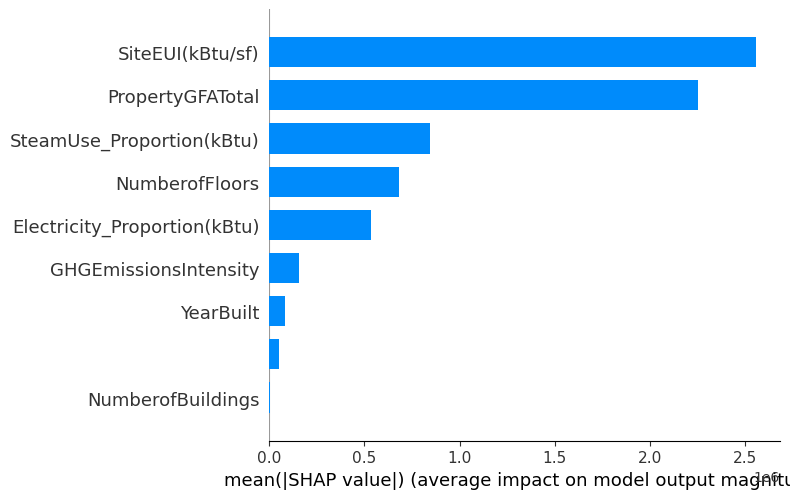

In [ ]:

# Utilisation de TreeExplainer pour RandomForest
explainer = shap.TreeExplainer(rf_model_best)
shap_values = explainer.shap_values(X_train)

# Visualisation
shap.summary_plot(shap_values, X_train, feature_names=X_train.columns, plot_type="bar")

<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> III.7 - Analyser de l'influence de ENERGYSTARScore </h4>
</div>

In [72]:
# Inclure ENERGYSTARScore dans les variables explicatives
X_include_ENERGYSTARScore = df.select(pl.exclude(["GHGEmissionsIntensity", "OSEBuildingID"]))
X_include_ENERGYSTARScore.head()

,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,SiteEUI(kBtu/sf),SiteEnergyUse(kBtu),ENERGYSTARScore,Electricity_Proportion(kBtu),SteamUse_Proportion(kBtu)
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64
0,1927,1.0,12.0,88434.0,81.699997,7226362.5,60.0,0.54606,0.277302
1,1996,1.0,11.0,103566.0,94.800003,8.387933e6,61.0,0.297569,0.23031
2,1969,1.0,2.0,47237.0,96.0,2.6152e6,43.0,0.405656,0.223646
3,1926,1.0,10.0,61320.0,110.800003,6.794584e6,56.0,0.407519,0.325913
4,1980,1.0,18.0,175580.0,114.800003,1.4172606e7,75.0,0.290734,0.23249


In [73]:
# Imputation des valeurs manquantes de ENERGYSTARScore par la moyenne
X_include_ENERGYSTARScore = X_include_ENERGYSTARScore.with_columns(
    pl.when(pl.col("ENERGYSTARScore").is_null())
    .then(pl.col("ENERGYSTARScore").fill_null(pl.col("ENERGYSTARScore").mean()))
    .otherwise(pl.col("ENERGYSTARScore"))
    .alias("ENERGYSTARScore")
)
# Séparation des variables explicatives (X) et de la variable cible (Y)
X_include_ENERGYSTARScore = X_include_ENERGYSTARScore.select(pl.exclude(["SiteEnergyUse(kBtu)", "OSEBuildingID"]))
Y_include_ENERGYSTARScore = df.select("SiteEnergyUse(kBtu)")
# 20% des données sont utilisées pour le test, et 80% pour l'entraînement et séparation reproductible à 42
X_train_include_ENERGYSTARScore, X_test_include_ENERGYSTARScore, y_train_include_ENERGYSTARScore, y_test_include_ENERGYSTARScore = train_test_split(
    X_include_ENERGYSTARScore, Y_include_ENERGYSTARScore, test_size=0.2, random_state=42
)

In [74]:
# Ajustement de la forme de y_train
y_train_include_ENERGYSTARScore = y_train_include_ENERGYSTARScore.to_numpy().ravel()
# Normalisation des données
scaler_include_ENERGYSTARScore = StandardScaler()
# Ajustement des données d'entraînement
X_train_include_ENERGYSTARScore_scaled = scaler_include_ENERGYSTARScore.fit_transform(X_train_include_ENERGYSTARScore)
# Normalisation des données de test
X_test_include_ENERGYSTARScore_scaled = scaler_include_ENERGYSTARScore.transform(X_test_include_ENERGYSTARScore)

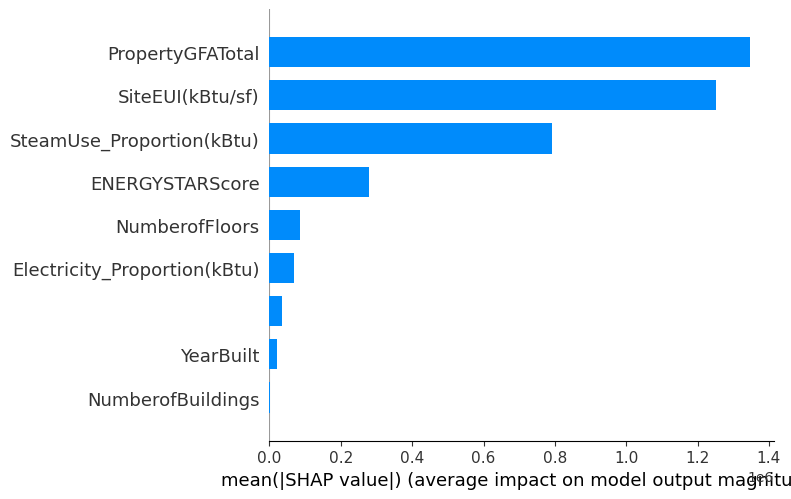

In [75]:
# Analyse de l'importance de la variable ENERGYSTARScore avec shap et visualisation
explainer_include_ENERGYSTARScore = shap.TreeExplainer(rf_model_best)
shap_values_include_ENERGYSTARScore = explainer_include_ENERGYSTARScore.shap_values(X_train_include_ENERGYSTARScore_scaled)
# Visualisation
shap.summary_plot(shap_values_include_ENERGYSTARScore, X_train_include_ENERGYSTARScore_scaled, feature_names=X_include_ENERGYSTARScore.columns, plot_type="bar")

##### Notes : L'importance de la variable ENERGYSTARScore dans le modèle RandomForest est relativement moyenne, elle est classé en 4ᵉ position parmi les 9 variables analysées.